In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv("../data/raw/fake_job_postings.csv")

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.shape


(17880, 18)

In [5]:
df.size

321840

In [6]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [8]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [9]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [11]:
df["fraudulent"].value_counts(normalize=True)*100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

In [12]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
df.select_dtypes(include="object").columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function'],
      dtype='object')

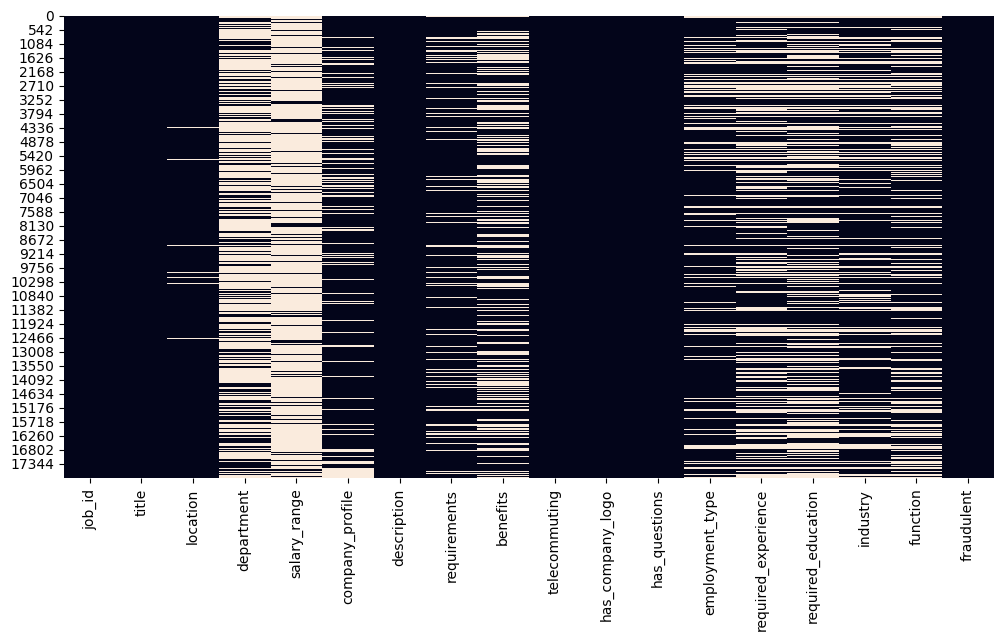

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [15]:
df["description_length"]=df["description"].fillna("").apply(len)

In [16]:
df["description_length"].describe()

count    17880.000000
mean      1217.989765
std        894.806698
min          0.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: description_length, dtype: float64

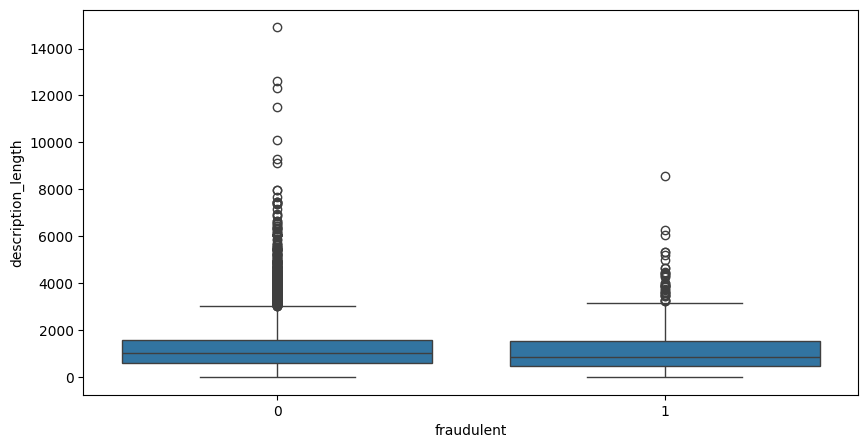

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="fraudulent",
    y="description_length",
    data=df
)
plt.show()

In [18]:
df["has_company_profile"]=(
    df["company_profile"].notnull().astype(int)
)

In [19]:
pd.crosstab(
    df["has_company_profile"],
    df["fraudulent"]
)

fraudulent,0,1
has_company_profile,,
0,2721,587
1,14293,279


In [20]:
df["requirements_length"]=(
    df["requirements"].fillna("").apply(len)
)

In [21]:
df["requirements_length"].describe()

count    17880.000000
mean       590.127125
std        613.185858
min          0.000000
25%        146.000000
50%        467.000000
75%        820.000000
max      10864.000000
Name: requirements_length, dtype: float64

In [22]:
numeric_cols=df.select_dtypes(
    include=["int64","float64"]
)
numeric_cols.corr()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent,description_length,has_company_profile,requirements_length
job_id,1.000000,-0.004559,-0.014539,-0.087025,0.079872,-0.017318,0.023061,-0.014162
telecommuting,-0.004559,1.000000,-0.019836,0.020345,0.034523,-0.006173,-0.065465,0.016673
has_company_logo,-0.014539,-0.019836,1.000000,0.233932,-0.261971,0.005446,0.694261,0.114672
has_questions,-0.087025,0.020345,0.233932,1.000000,-0.091627,-0.010910,0.154025,0.042311
fraudulent,0.079872,0.034523,-0.261971,-0.091627,1.000000,-0.015930,-0.286330,-0.053016
description_length,-0.017318,-0.006173,0.005446,-0.010910,-0.015930,1.000000,0.011083,0.089131
has_company_profile,0.023061,-0.065465,0.694261,0.154025,-0.286330,0.011083,1.000000,0.084079
requirements_length,-0.014162,0.016673,0.114672,0.042311,-0.053016,0.089131,0.084079,1.000000


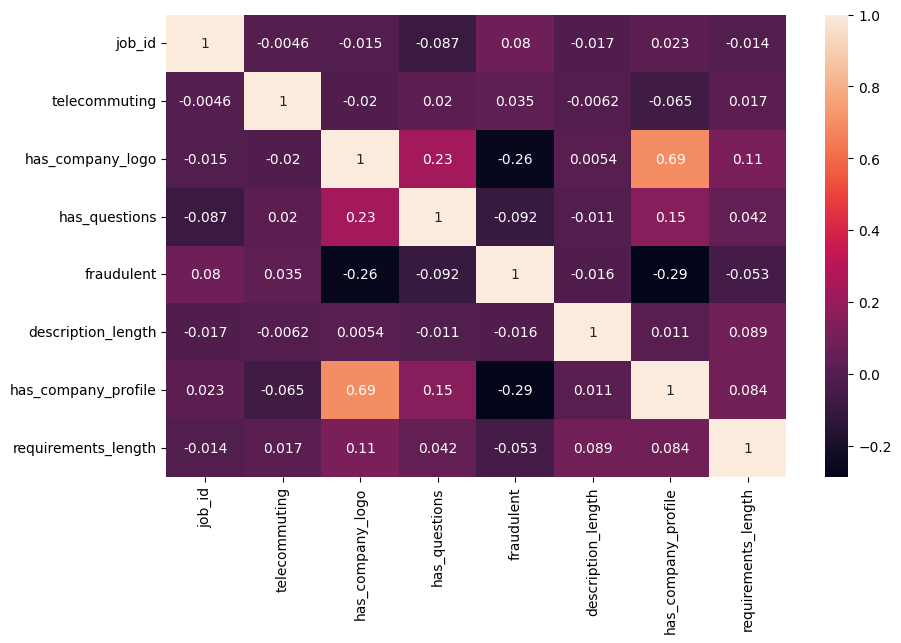

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True
)
plt.show()

# EDA Findings

1. Dataset is highly imbalanced.
2. Several columns contain missing values.
3. Fake jobs tend to have shorter descriptions.
4. Missing company profiles are common in fake jobs.
5. Requirements length may help identify scams.
6. Text-based features appear highly important.

In [24]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nikhil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nikhil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
df["text"] = (
    df["title"].fillna("") + " " +
    df["company_profile"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["requirements"].fillna("") + " " +
    df["benefits"].fillna("")
)

In [26]:
df['text']=df['text'].str.lower()

In [27]:
import re


In [28]:
def remove_punctuation(text):
    return re.sub(r'[^[a-zA-Z\s]','',text)

In [29]:
df["text"] = df["text"].apply(remove_punctuation)

In [30]:
from nltk.corpus import stopwords

In [31]:
stop_words = set(stopwords.words('english'))

In [32]:
def remove_stopwords(text):

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [33]:
df["text"] = df["text"].apply(remove_stopwords)

In [34]:
df["text"].head()

0    marketing intern food weve created groundbreak...
1    customer service cloud video production second...
2    commissioning machinery assistant cma valor se...
3    account executive washington dc passion improv...
4    bill review manager spotsource solutions llc g...
Name: text, dtype: object

In [36]:
df.to_csv(
    "../data/processed/cleaned_jobs.csv",
    index=False
)